##### 실행 환경 설정

In [7]:
# Google Drive를 Colab에 마운트
from google.colab import drive
drive.mount("/google_drive")

from pathlib import Path
from urllib.request import urlretrieve
import zipfile

# 작업 경로 설정
WORK_DIR = Path("/google_drive/Othercomputers/내 Mac/sec08")
if not WORK_DIR.exists():
    raise FileNotFoundError(f"작업 폴더를 찾을 수 없습니다: {WORK_DIR}")

print("\n[작업 폴더 목록]")
%cd {WORK_DIR}
!ls

# Colab 로컬 데이터셋 경로 설정
DATASET_ROOT = Path("/datasets")
DATASET_PATH = DATASET_ROOT / "coco128"
DATASET_ZIP = DATASET_ROOT / "coco128.zip"
DATASET_URL = (
    "https://github.com/ultralytics/assets/"
    "releases/download/v0.0.0/coco128.zip"
)

DATASET_READY = all(
    (DATASET_PATH / relative_path).exists()
    for relative_path in ["images/train2017", "labels/train2017"]
)

if not DATASET_READY:
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    print("\nCOCO128 데이터셋 다운로드 중...")
    urlretrieve(DATASET_URL, DATASET_ZIP)

    print("COCO128 데이터셋 압축 해제 중...")
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_file:
        zip_file.extractall(DATASET_ROOT)

    DATASET_ZIP.unlink(missing_ok=True)

print("\n[데이터셋 폴더 목록]")
print(DATASET_PATH)
!ls {DATASET_PATH}
print(DATASET_PATH / "images")
!ls {DATASET_PATH}/images
print(DATASET_PATH / "labels")
!ls {DATASET_PATH}/labels

# 한글 폰트 설치
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Drive already mounted at /google_drive; to attempt to forcibly remount, call drive.mount("/google_drive", force_remount=True).

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec08
01_object_detection_yolo_info.ipynb	      datasets
02_object_detection_yolo_dataset.ipynb	      detect
03_object_detection_yolo_train.ipynb	      runs
04_object_detection_yolo_visualization.ipynb  yolo11n.pt
05_segmentation_yolo_info.ipynb		      yolo11n-seg.pt
06_segmentation_yolo_train.ipynb	      yolo26n.pt
07_segmentation_yolo_visualization.ipynb      yolo26n-seg.pt

[데이터셋 폴더 목록]
/datasets/coco128
images	labels	LICENSE  README.txt
/datasets/coco128/images
train2017
/datasets/coco128/labels
train2017


##### 임포트

In [8]:
%pip install -q -U ultralytics

from ultralytics import YOLO
import torch
from pathlib import Path
from IPython.display import Image, display

##### YOLO 객체 탐지 모델 구조

In [9]:
# 사전 학습된 YOLO 모델 로드 (없으면 자동 다운로드)
model = YOLO("yolo26n.pt")

# 모델 구조 요약
model.info()
# Ultralytics 버전에 따라 레이어·파라미터·GFLOPs 수치는 달라질 수 있음
#   - layers    : 모델을 구성하는 총 레이어 수
#   - parameters: 학습 가능한 가중치의 총 개수
#   - gradients : 현재 역전파에 사용 중인 그래디언트 수 (추론 모드에서는 0)
#   - GFLOPs    : 이미지 1장 추론 시 필요한 연산량
# 반환값: (layers, parameters, gradients, GFLOPs) 튜플

print("-"*50)
print(model)

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs
--------------------------------------------------
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel

##### 사전 학습된 COCO 80개 클래스

In [10]:
# 모델이 인식 가능한 클래스 목록 (COCO 80개 클래스)
print(f"클래스 수: {len(model.names)} 개", type(model.names))
for key, value in model.names.items():
    print(f"  {key:2d}: {value}")

클래스 수: 80 개 <class 'dict'>
   0: person
   1: bicycle
   2: car
   3: motorcycle
   4: airplane
   5: bus
   6: train
   7: truck
   8: boat
   9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  

##### 추론해보기

In [11]:
# 샘플 이미지와 결과 저장 경로
image_path = DATASET_PATH / "images" / "train2017" / "000000000532.jpg"
PREDICT_PROJECT = Path(WORK_DIR) / "runs" / "detect"
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("사용 디바이스:", "cuda:0" if DEVICE == 0 else DEVICE)

# 추론 (verbose=False → 추론 로그 출력 숨김)
results = model(
    str(image_path),
    save=True,
    device=DEVICE,
    project=str(PREDICT_PROJECT),
    name="01",
    exist_ok=True,
    verbose=False
)

사용 디바이스: cuda:0
Results saved to /google_drive/Othercomputers/내 Mac/sec08/runs/detect/01


/google_drive/Othercomputers/내 Mac/sec08/runs/detect/01/000000000532.jpg


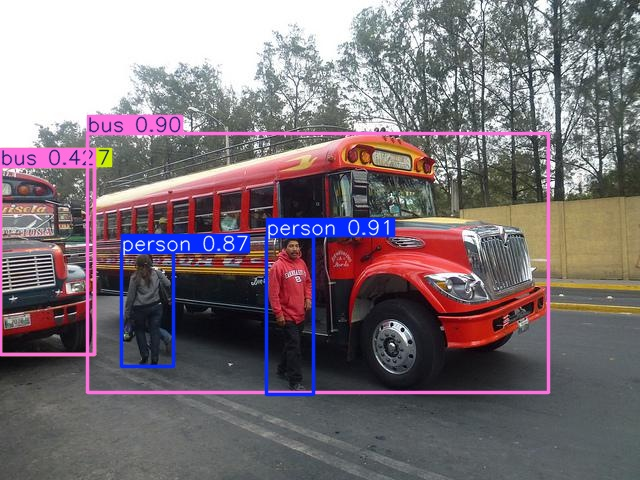

In [12]:
# 결과 이미지 출력
result_image_path = PREDICT_PROJECT / "01" / image_path.name
print(result_image_path)
display(Image(filename=str(result_image_path)))